In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns 


In [4]:
disease_df = pd.read_csv(r"C:\ML_Scikit\Datasets\framingham.csv")
disease_df.head(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
# Removing unwanted columns
disease_df.drop(columns= ['education'],inplace = True, axis = 1)
disease_df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
# this removes any rows with missing values Nan from the DataFrame
disease_df.dropna(axis = 0 , inplace = True)
disease_df

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [ ]:
# TenYearCHD  column which likely indicates that a patient has a heart disease or not 
print(disease_df.TenYearCHD.value_counts())

# THis below output means that 3179 patients doesnt have any heart disease and there are a total of 572 peoples that is facing heart disesase.


TenYearCHD
0    3179
1     572
Name: count, dtype: int64


In [10]:
X = np.asarray(disease_df[['age','male','cigsPerDay','totChol','sysBP','glucose']])

y = np.asarray(disease_df['TenYearCHD'])

X = preprocessing.StandardScaler().fit(X).transform(X)
# THis above code is doing a feature scaling on your input data X . If you train model without scaling features like totchol and sysBp dominate the model hust because their values are large . So preprocessing.standartscalar() creates a scalar objects and .fit(X) learns the mean and standard deviation of each coulumn in X. and .transform(X) applies the scaling formula to X

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state= 4)

# This splits datasets into training and testing parts . Test_size = 0.3 means that 30% of data is for the testing and 70% of data is for trianing the model and tha random state= 4 this makes the split reproducible same random split every time you run the code . without this every run gives a different split

print('Train set: ', X_train.shape, y_train.shape)

print('Test set: ', X_test.shape, y_test.shape)

Train set:  (2625, 6) (2625,)
Test set:  (1126, 6) (1126,)


C:\Users\Harshu\AppData\Local\Temp\ipykernel_21624\2039454370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= 'TenYearCHD', data= disease_df, palette = "BuGn_r")


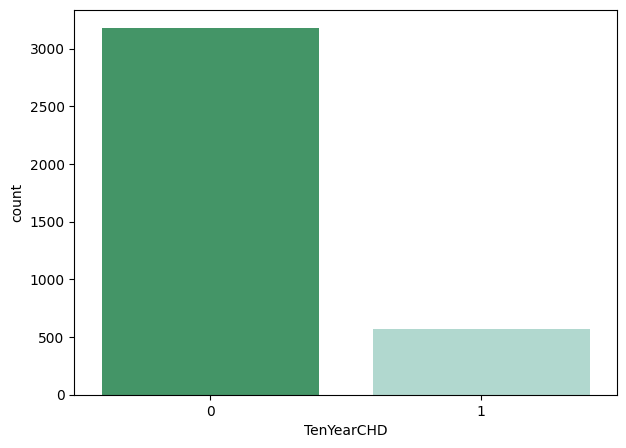

In [ ]:
# in EDA we perform EDA on the heart disease dataset to understand and gain insights into the database before building predictive model for heart disease


plt.figure(figsize=(7,5))
sns.countplot(x= 'TenYearCHD', data= disease_df, palette = "BuGn_r")
plt.show()

# The count plot shows a high imbalance in the dataset where the majority of individuals (over 3000) do not have heart disease (label 0) while only a small number (around 500) have heart disease (label 1).$

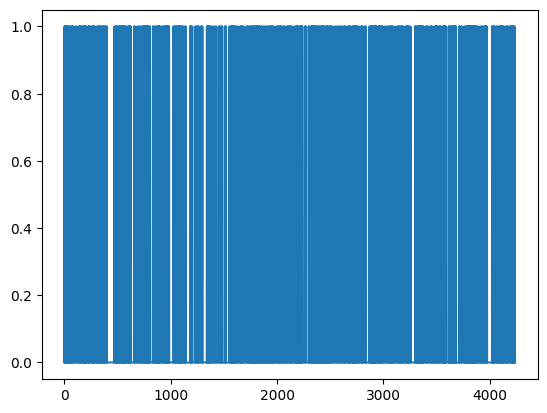

In [ ]:
# Counting number of patients affected by CHD where (0= Not Affected; 1= Affected)

laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

# Blue bars: Indicate the absence of heart disease.
# White space (gaps): These represent the presence of heart disease

In [ ]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

#logreg=LogisticRegression(): This creates an instance of the LogisticRegression model.
# logreg.fit(X_train, y_train): This trains the logistic regression model using the training data (X_train for features and y_train for the target).
# y_pred=logreg.predict(X_test): This uses the trained logistic regression model to make predictions on the test set (X_test). The predicted values are stored in y_pred.

In [14]:
from sklearn.metrics import accuracy_score
print('Accuracy of the model is = ',accuracy_score(y_test,y_pred))

Accuracy of the model is =  0.8490230905861457


The details for the confusion matrix is : 
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       951
           1       0.61      0.08      0.14       175

    accuracy                           0.85      1126
   macro avg       0.73      0.54      0.53      1126
weighted avg       0.82      0.85      0.80      1126



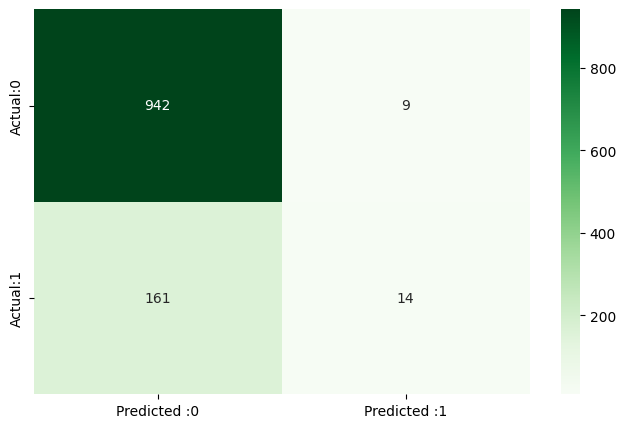

In [16]:
# Plotting confusion matrix 

from sklearn.metrics import confusion_matrix , classification_report

print('The details for the confusion matrix is : ')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test,y_pred)
conf_matrix = pd.DataFrame(data = cm, columns = ['Predicted :0','Predicted :1'],index = ['Actual:0','Actual:1'])

plt.figure(figsize= (8,5))
sns.heatmap(conf_matrix,annot = True, fmt = 'd',cmap = "Greens")

plt.show()